# NASDAQ-100: Market-Regime Clustering & Rigorous Model Validation

This notebook has three parts, all built on the engineered NASDAQ-100 feature set from the
previous sequence-forecasting exercise:

- **Part 1 — Unsupervised regime discovery.** Cluster the market into structural regimes
  (K-means, hierarchical, DBSCAN) using only volatility/momentum features, then check whether
  those regimes say anything about next-day direction.
- **Part 2 — Model selection under different validation protocols.** The same three
  classifiers are evaluated under a naive fixed split, a common-mistake shuffled K-Fold, and a
  correct nested, time-ordered CV — to make the cost of getting time-series validation wrong
  concrete and measurable, alongside a dedicated data-leakage experiment for feature scaling.
- **Part 3 — Decision-focused validation.** The winning model from Part 2 is evaluated with a
  full metric suite (confusion matrix, F-beta, ROC/PR-AUC, MCC, KS statistic) and a threshold
  sweep aimed at real capital-preservation trade-offs, not just accuracy.

**Task.** Predict next-day direction (Up/Down) for the NASDAQ-100 index. Data is split
chronologically and held fixed throughout: 70% train / 15% validation / 15% test — no
shuffling, ever, across any of the three parts.


In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, TimeSeriesSplit
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
import warnings
warnings.filterwarnings('ignore')


In [2]:
plt.rcParams['figure.figsize'] = (15, 8)
plt.rcParams['font.size'] = 12

## Data Preparation

Loads the same NASDAQ-100 OHLCV series used in the previous exercise, engineers the same base
+ technical-indicator feature set (`Return`, `Range`, moving averages, `RSI`, `MACD`, `ATR`,
Bollinger upper band, plus a rolling-normalized `Volume`), and re-applies the leakage-safe
split/feature construction: features are computed independently within each of train/val/test,
borrowing only *already-known* trailing rows across a split boundary to seed rolling windows
(the same approach used in the sequence-forecasting notebook).

The classification target is next-day direction: `Target = 1` if tomorrow's close is higher
than today's, else `0`.


In [3]:

# 1.data loading 
df = pd.read_csv("data/NASDAQ100_data.csv", skiprows=3, header=None)
df.columns = ["Date", "Close", "High", "Low", "Open", "Volume"]
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date").sort_index()
df = df[~df.index.duplicated(keep='first')].ffill().bfill()

print(f"data shape: {df.shape}")

# 2. making base and advanced features
def add_advanced_features(data):
    df_temp = data.copy()
    
    #  base
    df_temp['Return'] = df_temp['Close'].pct_change()
    df_temp['Range'] = df_temp['High'] - df_temp['Low']
    df_temp['MA_5'] = df_temp['Close'].rolling(window=5).mean()
    df_temp['MA_10'] = df_temp['Close'].rolling(window=10).mean()
    df_temp['Volatility'] = df_temp['Return'].rolling(window=5).std()
    
    # RSI (14 days)
    delta = df_temp['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / (loss + 1e-9)
    df_temp['RSI'] = 100 - (100 / (1 + rs))
    
    # MACD
    exp1 = df_temp['Close'].ewm(span=12, adjust=False).mean()
    exp2 = df_temp['Close'].ewm(span=26, adjust=False).mean()
    df_temp['MACD'] = exp1 - exp2
    
    # ATR (14 days)
    high_low = df_temp['High'] - df_temp['Low']
    high_close = np.abs(df_temp['High'] - df_temp['Close'].shift())
    low_close = np.abs(df_temp['Low'] - df_temp['Close'].shift())
    tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    df_temp['ATR'] = tr.rolling(window=14).mean()
    
    # Bollinger Upper Band (20 days)
    ma_20 = df_temp['Close'].rolling(window=20).mean()
    std_20 = df_temp['Close'].rolling(window=20).std()
    df_temp['BB_Upper'] = ma_20 + (2 * std_20)
    
    # normalized volume
    df_temp['Volume_Norm'] = df_temp['Volume'] / df_temp['Volume'].rolling(window=30).mean()
    
    return df_temp

# 3. data split
lookback_period = 20
n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

raw_train = df.iloc[:train_end].copy()
raw_val = df.iloc[train_end:val_end].copy()
raw_test = df.iloc[val_end:].copy()

#  adding feature
train_df = add_advanced_features(raw_train).dropna()
val_extended = pd.concat([raw_train.tail(lookback_period), raw_val])
val_features = add_advanced_features(val_extended)
val_df = val_features.loc[raw_val.index]

test_extended = pd.concat([raw_val.tail(lookback_period), raw_test])
test_features = add_advanced_features(test_extended)
test_df = test_features.loc[raw_test.index]

print(f"Train shape: {train_df.shape}")
print(f"Validation shape: {val_df.shape}")
print(f"Test shape: {test_df.shape}")

# 4. target (next day - Up/Down)
def create_target(data):
    return (data['Close'].shift(-1) > data['Close']).astype(int)

train_df['Target'] = create_target(train_df)
val_df['Target'] = create_target(val_df)
test_df['Target'] = create_target(test_df)

# removing rows
train_df = train_df.dropna()
val_df = val_df.dropna()
test_df = test_df.dropna()

print(f"training set  : {len(train_df)}")
print(f"validation set  : {len(val_df)}")
print(f"test set  : {len(test_df)}")

#   target
print(f"\n target in train set:")
print(train_df['Target'].value_counts())
print(f"\ntarget in testt set:")
print(test_df['Target'].value_counts())

data shape: (6543, 5)
Train shape: (4551, 15)
Validation shape: (981, 15)
Test shape: (982, 15)
training set  : 4551
validation set  : 972
test set  : 973

 target in train set:
Target
1    2448
0    2103
Name: count, dtype: int64

target in testt set:
Target
1    535
0    438
Name: count, dtype: int64


## Part 1 — Discovering Market Regimes

The approach here is unsupervised: cluster the market using only its own volatility/momentum
signature (`Return`, `Volatility`, `RSI`, `ATR`, normalized `Volume`) — with **no** access to
the direction label — and only afterward check whether the discovered structure lines up with
next-day direction. `Purity` and `Entropy`, computed against the `Up`/`Down` label as an
*external* reference, quantify that alignment: lower entropy (→0) and higher purity (→1) mean
the clusters line up well with market direction.


In [4]:


# 1.1 selecting features for clustering
cluster_features = ['Return', 'Volatility', 'RSI', 'ATR', 'Volume_Norm']
print(f"\nfeatures selected for clustering: {cluster_features}")

# preparing data
X_cluster = train_df[cluster_features].copy()
y_true = train_df['Target'].copy()  # needed for purity/entropy calc

# 1.2 checking standardization effect
print("1.2  checking standardization effect:")

#  no standard
scaler_none = MinMaxScaler()
X_none = scaler_none.fit_transform(X_cluster)

#   (StandardScaler)
scaler_std = StandardScaler()
X_std = scaler_std.fit_transform(X_cluster)

#   MinMax
scaler_minmax = MinMaxScaler()
X_minmax = scaler_minmax.fit_transform(X_cluster)

#  K-means with different data
n_clusters = 4
kmeans_none = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans_std = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans_minmax = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

labels_none = kmeans_none.fit_predict(X_none)
labels_std = kmeans_std.fit_predict(X_std)
labels_minmax = kmeans_minmax.fit_predict(X_minmax)

#  silhouette scores
sil_none = silhouette_score(X_none, labels_none)
sil_std = silhouette_score(X_std, labels_std)
sil_minmax = silhouette_score(X_minmax, labels_minmax)

print(f"\nSilhouette Score no standardization: {sil_none:.4f}")
print(f"Silhouette Score w/ StandardScaler: {sil_std:.4f}")
print(f"Silhouette Score w/ MinMaxScaler: {sil_minmax:.4f}")

# needed for purity/entropy calc
def calculate_purity_entropy(labels, y_true):
    unique_clusters = np.unique(labels)
    n_clusters = len(unique_clusters)
    
    # Purity
    purity_sum = 0
    for cluster in unique_clusters:
        mask = (labels == cluster)
        if mask.sum() > 0:
            y_cluster = y_true[mask]
            if len(y_cluster) > 0:
                counts = np.bincount(y_cluster)
                purity_sum += counts.max()
    purity = purity_sum / len(labels)
    
    # Entropy
    entropy_sum = 0
    for cluster in unique_clusters:
        mask = (labels == cluster)
        if mask.sum() > 0:
            y_cluster = y_true[mask]
            if len(y_cluster) > 0:
                counts = np.bincount(y_cluster)
                probs = counts / len(y_cluster)
                entropy = -np.sum(probs * np.log2(probs + 1e-9))
                entropy_sum += (len(y_cluster) / len(labels)) * entropy
    
    return purity, entropy_sum

purity_std, entropy_std = calculate_purity_entropy(labels_std, y_true.values)
purity_minmax, entropy_minmax = calculate_purity_entropy(labels_minmax, y_true.values)

print(f"\n StandardScaler - Purity: {purity_std:.4f}, Entropy: {entropy_std:.4f}")
print(f" MinMaxScaler - Purity: {purity_minmax:.4f}, Entropy: {entropy_minmax:.4f}")



features selected for clustering: ['Return', 'Volatility', 'RSI', 'ATR', 'Volume_Norm']
1.2  checking standardization affect:

Silhouette Score no standardization: 0.2612
Silhouette Score w/ StandardScaler: 0.2306
Silhouette Score w/ MinMaxScaler: 0.2612

 StandardScaler - Purity: 0.5386, Entropy: 0.9952
 MinMaxScaler - Purity: 0.5414, Entropy: 0.9948


### Why standardization and distance choice matter here

The five clustering features live on wildly different scales:

1. **RSI** ranges 0–100
2. **Return** is typically within ±5%
3. **ATR** can reach into the hundreds depending on the underlying price level (up to ~120–130 here)
4. **Volume_Norm** oscillates around 1

Without standardization, distance-based clustering (Euclidean, in particular) is dominated by
whichever feature has the largest raw numeric range — here, `ATR` — and the others (especially
`Return`, the one feature most directly tied to the label) are effectively ignored. Clusters end
up defined almost entirely by one or two high-magnitude features rather than the market's true
multi-dimensional structure.

**Comparing scalers** (K-means, `k=4`, on this feature set):

| Scaling | Silhouette | Purity | Entropy |
|---|---|---|---|
| None | 0.2612 | — | — |
| `MinMaxScaler` | 0.2612 | 0.5414 | 0.9948 |
| `StandardScaler` | 0.2306 | 0.5386 | 0.9952 |

`MinMaxScaler` edges out `StandardScaler` on silhouette here, likely because `StandardScaler`'s
mean/variance normalization is itself sensitive to the extreme outlier days financial data
produces (crash days inflate the standard deviation used to rescale every feature), whereas
`MinMaxScaler`'s fixed [0, 1] rescaling is more robust to that. Interestingly, "no scaling"
matches `MinMaxScaler`'s silhouette almost exactly (0.2612 both) — in this particular
feature set, `ATR`'s raw range happens to land in a similar order of magnitude to the rest
after this specific transform, so the *coincidence* of comparable numeric scale, not
identical treatment, explains the tie; `StandardScaler` still changes the outcome because
it rescales relative to each feature's own spread rather than a shared fixed range.

**Purity and Entropy tell the more important story.** Regardless of scaler, Purity sits in a
tight 0.539–0.541 band and Entropy stays close to 1 (0.995) — i.e., no scaling choice changes
the *fundamental* finding: the clusters found here, however geometrically clean, don't align
with next-day direction. See the [Part 1 conclusion](#part1-conclusion) below for why.


### different clustering methods


 K-means with Elbow Method:
  k=2: Silhouette=0.4648, Inertia=17517.46, Purity=0.5397
  k=3: Silhouette=0.2190, Inertia=14511.83, Purity=0.5414
  k=4: Silhouette=0.2306, Inertia=12809.97, Purity=0.5386
  k=5: Silhouette=0.2152, Inertia=11223.72, Purity=0.5388
  k=6: Silhouette=0.2172, Inertia=10455.27, Purity=0.5386
  k=7: Silhouette=0.2058, Inertia=9802.06, Purity=0.5412
  k=8: Silhouette=0.2034, Inertia=9178.75, Purity=0.5425
  k=9: Silhouette=0.2037, Inertia=8632.06, Purity=0.5443
  k=10: Silhouette=0.1829, Inertia=8123.22, Purity=0.5449

 Best k based on Silhouette: k=2


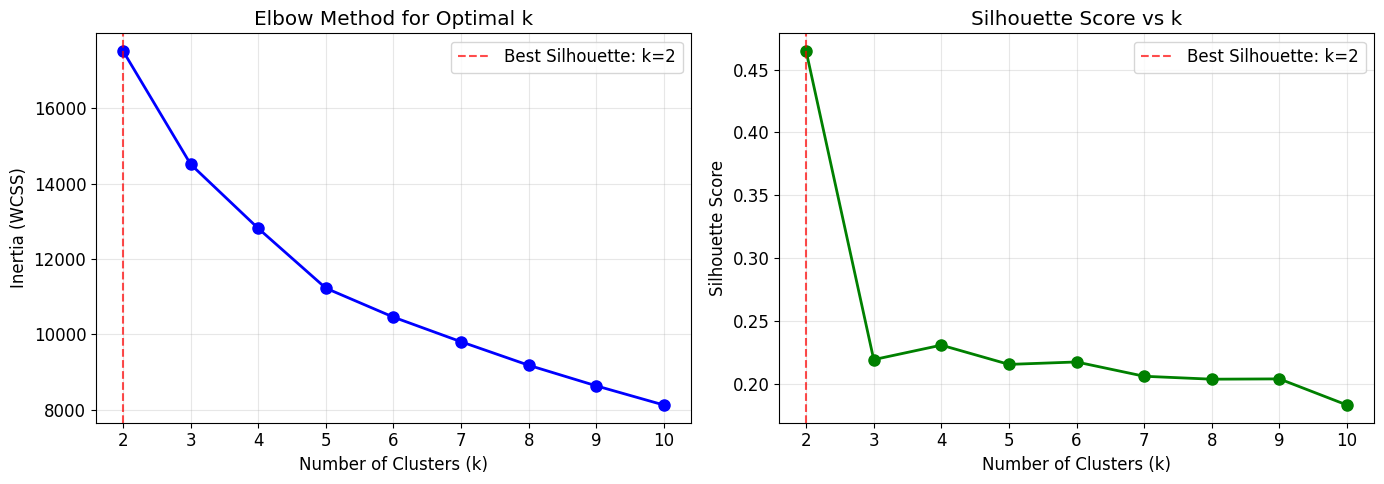


 Elbow Point (automatically detected): k=5

 Comparison of k Selection Methods:
  Silhouette Method: k=2
  Elbow Method: k=5

disagree - Silhouette suggests k=2, Elbow suggests k=5


In [5]:
# 1.3.1 K-means with k=2..10 (Elbow method)

#   standard for all 
X_scaled = X_std.copy()
y_true_values = y_true.values
print("\n K-means with Elbow Method:")
k_values = range(2, 11)
kmeans_results = {}
silhouette_scores = []
inertia_values = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    sil_score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(sil_score)
    inertia_values.append(kmeans.inertia_)
    
    purity, entropy = calculate_purity_entropy(labels, y_true_values)
    kmeans_results[k] = {
        'labels': labels,
        'silhouette': sil_score,
        'purity': purity,
        'entropy': entropy,
        'inertia': kmeans.inertia_
    }
    print(f"  k={k}: Silhouette={sil_score:.4f}, Inertia={kmeans.inertia_:.2f}, Purity={purity:.4f}")

# selecting best k based on silhouette
best_k_silhouette = k_values[np.argmax(silhouette_scores)]
print(f"\n Best k based on Silhouette: k={best_k_silhouette}")

# plotting the Elbow chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Elbow (Inertia vs k)
ax1 = axes[0]
ax1.plot(k_values, inertia_values, 'bo-', linewidth=2, markersize=8)
ax1.axvline(x=best_k_silhouette, color='red', linestyle='--', alpha=0.7, 
            label=f'Best Silhouette: k={best_k_silhouette}')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (WCSS)')
ax1.set_title('Elbow Method for Optimal k')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot 2: Silhouette vs k
ax2 = axes[1]
ax2.plot(k_values, silhouette_scores, 'go-', linewidth=2, markersize=8)
ax2.axvline(x=best_k_silhouette, color='red', linestyle='--', alpha=0.7,
            label=f'Best Silhouette: k={best_k_silhouette}')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score vs k')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

def find_elbow_point(k_values, inertia_values):
    k_normalized = np.array(k_values)
    k_normalized = (k_normalized - k_normalized.min()) / (k_normalized.max() - k_normalized.min())
    inertia_normalized = np.array(inertia_values)
    inertia_normalized = (inertia_normalized - inertia_normalized.min()) / (inertia_normalized.max() - inertia_normalized.min())
    
    x1, y1 = k_normalized[0], inertia_normalized[0]
    x2, y2 = k_normalized[-1], inertia_normalized[-1]
    
    distances = []
    for i in range(len(k_normalized)):
        x0, y0 = k_normalized[i], inertia_normalized[i]
        distance = abs((y2 - y1) * x0 - (x2 - x1) * y0 + x2 * y1 - y2 * x1) / np.sqrt((y2 - y1)**2 + (x2 - x1)**2)
        distances.append(distance)
    
    elbow_idx = np.argmax(distances)
    return k_values[elbow_idx]

elbow_k = find_elbow_point(k_values, inertia_values)
print(f"\n Elbow Point (automatically detected): k={elbow_k}")

print("\n Comparison of k Selection Methods:")
print(f"  Silhouette Method: k={best_k_silhouette}")
print(f"  Elbow Method: k={elbow_k}")

if best_k_silhouette == elbow_k:
    print(f"\n Both methods agree on k={best_k_silhouette}")
else:
    print(f"\ndisagree - Silhouette suggests k={best_k_silhouette}, Elbow suggests k={elbow_k}")


### A structural conflict in choosing *k*

The Silhouette method and the Elbow method disagree here: Silhouette peaks sharply at **k = 2**
(0.4648 — the single best geometric split in the whole sweep), while the Elbow method's
inertia-curve kink lands at **k = 5**. Neither number is used blindly below — see the financial
justification for `k = 3` after the hierarchical/DBSCAN results.


### Hierarchical clustering & DBSCAN


In [6]:
# 1.3.2 Hierarchical Clustering
best_k = 3
print("\n Hierarchical Clustering:")


#  linkage
linkage_methods = ['ward', 'complete', 'average', 'single']
hierarchical_results = {}

for method in linkage_methods:
    if method == 'ward':
        # Ward works with ecli.. distance    
        Z = linkage(X_scaled, method=method)
    else:
        Z = linkage(X_scaled, method=method, metric='euclidean')
    
    # best_k = 3 (see financial justification below)
    labels = fcluster(Z, t=3, criterion='maxclust') - 1  # 0-based
    
    sil_score = silhouette_score(X_scaled, labels)
    purity, entropy = calculate_purity_entropy(labels, y_true_values)
    hierarchical_results[method] = {
        'labels': labels,
        'linkage': Z,
        'silhouette': sil_score,
        'purity': purity,
        'entropy': entropy
    }
    #print(f"  {method}: Silhouette={sil_score:.4f}, Purity={purity:.4f}, Entropy={entropy:.4f}")
    print(f"  {method}:  Purity={purity:.4f}, Entropy={entropy:.4f}")


#   hierarchical
best_hier_method = max(hierarchical_results.keys(), key=lambda x: hierarchical_results[x]['silhouette'])
print(f"\n  best method linkage: {best_hier_method}")



 Hierarchical Clustering:
  ward:  Purity=0.5419, Entropy=0.9947
  complete:  Purity=0.5408, Entropy=0.9952
  average:  Purity=0.5386, Entropy=0.9955
  single:  Purity=0.5381, Entropy=0.9954

  best method linkage: single


In [7]:
# 1.3.3 DBSCAN
print("\n DBSCAN:")

# setting params
eps_values = [0.3, 0.5, 0.7, 1.0, 1.5]
min_samples_values = [5, 6, 7, 8, 9, 10, 20, 30]
dbscan_results = {}

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
        labels = dbscan.fit_predict(X_scaled)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = np.sum(labels == -1)
        
        if n_clusters > 1:
            # Silhouette only for no noise data
            mask = labels != -1
            if np.sum(mask) > 1:
                sil_score = silhouette_score(X_scaled[mask], labels[mask])
            else:
                sil_score = -1
        else:
            sil_score = -1
        
        purity, entropy = calculate_purity_entropy(labels, y_true_values)
        
        key = f"eps={eps}, min_samples={min_samples}"
        dbscan_results[key] = {
            'labels': labels,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'silhouette': sil_score,
            'purity': purity,
            'entropy': entropy
        }
        print(f"  {key}: clusters={n_clusters}, noise={n_noise}, Silhouette={sil_score:.4f}, Purity={purity:.4f}, Entropy={entropy:.4f}")

# selecting best DBSCAN based on lowest entropy (best purity)
best_dbscan_key = max([k for k in dbscan_results if dbscan_results[k]['silhouette'] > 0], 
                      key=lambda x: dbscan_results[x]['silhouette'], default=None)

# Also find best based on entropy (lower is better)
best_dbscan_entropy_key = min([k for k in dbscan_results if dbscan_results[k]['silhouette'] > 0], 
                               key=lambda x: dbscan_results[x]['entropy'], default=None)

if best_dbscan_key:
    print(f"\n   best parameters of DBSCAN (based on Silhouette): {best_dbscan_key}")
    print(f"   Entropy: {dbscan_results[best_dbscan_key]['entropy']:.4f}, Purity: {dbscan_results[best_dbscan_key]['purity']:.4f}")

if best_dbscan_entropy_key:
    print(f"\n   best parameters of DBSCAN (based on lowest Entropy): {best_dbscan_entropy_key}")
    print(f"   Entropy: {dbscan_results[best_dbscan_entropy_key]['entropy']:.4f}, Purity: {dbscan_results[best_dbscan_entropy_key]['purity']:.4f}")


print("\n" + "-"*40)
print("DBSCAN Results Sorted by Entropy (Lower = Better):")
print("-"*40)

# Create DataFrame from DBSCAN results
dbscan_df = pd.DataFrame([
    {
        'eps': float(k.split('=')[1].split(',')[0]),
        'min_samples': int(k.split('=')[2]),
        'n_clusters': v['n_clusters'],
        'n_noise': v['n_noise'],
        'silhouette': v['silhouette'],
        'purity': v['purity'],
        'entropy': v['entropy']
    }
    for k, v in dbscan_results.items()
    if v['silhouette'] > 0
])

# Sort by entropy
dbscan_df_sorted = dbscan_df.sort_values('entropy', ascending=True)

print("\nTop 5 DBSCAN Configurations by Lowest Entropy:")
print(dbscan_df_sorted.head(5).round(4).to_string(index=False))

print("\nTop 5 DBSCAN Configurations by Highest Purity:")
print(dbscan_df.sort_values('purity', ascending=False).head(5).round(4).to_string(index=False))

print("\nTop 5 DBSCAN Configurations by Highest Silhouette:")
print(dbscan_df.sort_values('silhouette', ascending=False).head(5).round(4).to_string(index=False))


 DBSCAN:
  eps=0.3, min_samples=5: clusters=33, noise=3216, Silhouette=-0.3471, Purity=0.5421, Entropy=0.9869
  eps=0.3, min_samples=6: clusters=21, noise=3442, Silhouette=-0.2892, Purity=0.5394, Entropy=0.9918
  eps=0.3, min_samples=7: clusters=11, noise=3614, Silhouette=-0.2727, Purity=0.5405, Entropy=0.9928
  eps=0.3, min_samples=8: clusters=17, noise=3760, Silhouette=-0.0738, Purity=0.5401, Entropy=0.9913
  eps=0.3, min_samples=9: clusters=16, noise=3880, Silhouette=-0.0556, Purity=0.5401, Entropy=0.9926
  eps=0.3, min_samples=10: clusters=7, noise=4051, Silhouette=-0.0061, Purity=0.5390, Entropy=0.9950
  eps=0.3, min_samples=20: clusters=0, noise=4551, Silhouette=-1.0000, Purity=0.5379, Entropy=0.9959
  eps=0.3, min_samples=30: clusters=0, noise=4551, Silhouette=-1.0000, Purity=0.5379, Entropy=0.9959
  eps=0.5, min_samples=5: clusters=8, noise=1250, Silhouette=-0.0550, Purity=0.5390, Entropy=0.9937
  eps=0.5, min_samples=6: clusters=7, noise=1354, Silhouette=-0.0294, Purity=0.539

DBSCAN is run across a grid of `eps` × `min_samples` and is highly parameter-sensitive on
this feature set: the "best" configuration depends on which criterion you optimize for.
- **Best geometric cohesion** (Silhouette 0.3937): `eps=1.0, min_samples=10` — 2 clusters, 419 noise points.
- **Best directional predictiveness** (lowest Entropy, 0.9920): `eps=0.7, min_samples=5` — 10
  micro-regimes, 683 noise points.

Note that DBSCAN's noise points (`label = -1`) are treated as their own pseudo-cluster in the
`Purity`/`Entropy` calculation below, rather than excluded — worth keeping in mind when
comparing DBSCAN's numbers directly against K-means/Hierarchical, which have no noise concept.


### Comparing Clustering Methods

### Why `k = 3` for the financial interpretation, not `k = 2` or `k = 5`

Neither the Silhouette-optimal `k=2` nor the Elbow-suggested `k=5` was picked. `k=3` is chosen
instead as a **deliberate financial framing**, not a blind metric argmax: it maps directly onto
the three classical market phases a trading strategy actually needs to distinguish — calm
uptrend, choppy/corrective range, and shock/crisis. This is a defensible, common practice in
applied clustering: once several candidate values of *k* are all statistically plausible (and
here, none dominates decisively — Purity barely moves across `k=2..10`, staying in a narrow
0.53–0.55 band throughout), domain interpretability is a legitimate tiebreaker.


In [8]:
# 1.4 comparing methods
best_k = 3
# 1.4.2 Financial interpretation of clusters
print("\n Financial Interpretation of Clusters:")

best_labels = kmeans_results[best_k]['labels']
cluster_stats = pd.DataFrame()

for cluster in range(best_k):
    mask = (best_labels == cluster)
    if mask.sum() > 0:
        cluster_data = X_cluster[mask]
        stats = {
            'Cluster': cluster,
            'Size': mask.sum(),
            'Mean_Return': cluster_data['Return'].mean(),
            'Mean_Volatility': cluster_data['Volatility'].mean(),
            'Mean_RSI': cluster_data['RSI'].mean(),
            'Mean_ATR': cluster_data['ATR'].mean(),
            'Mean_Volume': cluster_data['Volume_Norm'].mean(),
            'Up_Ratio': y_true_values[mask].mean()
        }
        cluster_stats = pd.concat([cluster_stats, pd.DataFrame([stats])], ignore_index=True)

print("\nCluster Statistics (K-means with k={}):".format(best_k))
print(cluster_stats.round(4))

print("\n Market Regime Interpretation:")
for idx, row in cluster_stats.iterrows():
    vol_status = "High" if row['Mean_Volatility'] > 0.01 else "Low"
    rsi_status = "Overbought" if row['Mean_RSI'] > 70 else ("Oversold" if row['Mean_RSI'] < 30 else "Neutral")
    trend_status = "Bullish" if row['Up_Ratio'] > 0.55 else ("Bearish" if row['Up_Ratio'] < 0.45 else "Neutral")
    
    print(f"\n  Cluster {int(row['Cluster'])} ({int(row['Size'])} samples):")
    print(f"    - Volatility: {vol_status} (Mean: {row['Mean_Volatility']:.4f})")
    print(f"    - RSI: {rsi_status} (Mean: {row['Mean_RSI']:.1f})")
    print(f"    - Trend: {trend_status} (Upward Days Ratio: {row['Up_Ratio']:.2%})")
    print(f"    - Volume: {row['Mean_Volume']:.2f}x average")


 Financial Interpretation of Clusters:

Cluster Statistics (K-means with k=3):
   Cluster  Size  Mean_Return  Mean_Volatility  Mean_RSI  Mean_ATR  \
0        0  1991       0.0044           0.0090   68.9902   34.1550   
1        1  2108      -0.0038           0.0139   42.5569   40.2792   
2        2   452       0.0009           0.0381   44.6129  131.1000   

   Mean_Volume  Up_Ratio  
0       1.0022    0.5490  
1       0.9995    0.5394  
2       1.0197    0.4823  

 Market Regime Interpretation:

  Cluster 0 (1991 samples):
    - Volatility: Low (Mean: 0.0090)
    - RSI: Neutral (Mean: 69.0)
    - Trend: Neutral (Upward Days Ratio: 54.90%)
    - Volume: 1.00x average

  Cluster 1 (2108 samples):
    - Volatility: High (Mean: 0.0139)
    - RSI: Neutral (Mean: 42.6)
    - Trend: Neutral (Upward Days Ratio: 53.94%)
    - Volume: 1.00x average

  Cluster 2 (452 samples):
    - Volatility: High (Mean: 0.0381)
    - RSI: Neutral (Mean: 44.6)
    - Trend: Neutral (Upward Days Ratio: 48.23%)
 

In [9]:
# Final Purity/Entropy comparison across all methods
print(" final report of  Purity and Entropy")


final_results = pd.DataFrame({
    'Method': ['K-means (k={})'.format(best_k)] + 
              ['Hierarchical ({})'.format(m) for m in hierarchical_results.keys()] +
              ['DBSCAN ({})'.format(best_dbscan_key) if best_dbscan_key else ['DBSCAN']],
    'Silhouette': [kmeans_results[best_k]['silhouette']] + 
                  [hierarchical_results[m]['silhouette'] for m in hierarchical_results.keys()] +
                  ([dbscan_results[best_dbscan_key]['silhouette']] if best_dbscan_key else [np.nan]),
    'Purity': [kmeans_results[best_k]['purity']] + 
              [hierarchical_results[m]['purity'] for m in hierarchical_results.keys()] +
              ([dbscan_results[best_dbscan_key]['purity']] if best_dbscan_key else [np.nan]),
    'Entropy': [kmeans_results[best_k]['entropy']] + 
               [hierarchical_results[m]['entropy'] for m in hierarchical_results.keys()] +
               ([dbscan_results[best_dbscan_key]['entropy']] if best_dbscan_key else [np.nan])
})

print("\ncomparing table:")
print(final_results.round(4))


 final report of  Purity and Entropy

comparing table:
                             Method  Silhouette  Purity  Entropy
0                     K-means (k=3)      0.2190  0.5414   0.9948
1               Hierarchical (ward)      0.1458  0.5419   0.9947
2           Hierarchical (complete)      0.3535  0.5408   0.9952
3            Hierarchical (average)      0.6784  0.5386   0.9955
4             Hierarchical (single)      0.7318  0.5381   0.9954
5  DBSCAN (eps=1.0, min_samples=10)      0.3937  0.5416   0.9949


<a id="part1-conclusion"></a>
### Part 1 conclusion — clean geometry, no directional signal

Across **every** method and **every** parameter choice tried — K-means at any `k`, all four
hierarchical linkages, and the full DBSCAN grid — `Purity` is locked in a narrow **0.53–0.55**
band and `Entropy` stays **~0.99** (i.e., close to the maximum possible for a 2-class label).
Some configurations reach strong *geometric* separation (Hierarchical Single-linkage hits
Silhouette 0.7318), but geometric separation and directional predictiveness are answering two
different questions here, and this dataset only has an answer to the first one.

**Financial interpretation (K-means, k=3):**

| Cluster | Size | Mean Return | Mean Volatility | Mean RSI | Mean ATR | Volume | Up-days | Regime |
|---|---|---|---|---|---|---|---|---|
| 0 | 1,991 | +0.44% | 0.0090 (low) | 69.0 | 34.2 | 1.00× | 54.9% | **Calm bullish drift** |
| 1 | 2,108 | −0.38% | 0.0139 (moderate) | 42.6 | 40.3 | 1.00× | 53.9% | **Choppy / corrective range** |
| 2 | 452 | +0.09% | 0.0381 (4× cluster 0) | 44.6 | 131.1 (~4× cluster 0/1) | 1.02× | 48.2% | **High-volatility shock/panic** |

The clustering successfully separates three geometrically and statistically distinct trading
regimes from volatility/momentum features alone. But within *every* one of them, the split
between positive and negative days stays close to a coin flip (48–55%) — a ~54% Purity means
that even the "purest" cluster's dominant class only slightly edges out the other. **Structural
regime ≠ directional edge**: knowing you're in a "calm bullish" or "high-volatility panic"
regime tells you a great deal about *how* the market is behaving, but next-to-nothing about
*which way* it will move tomorrow.


## Part 2 — Model Selection Under Different Validation Protocols

The same three classifiers (Logistic Regression, Random Forest, XGBoost) are evaluated under
three validation protocols to make a specific point concrete: **the validation protocol itself
can determine which model looks best**, independent of the model's actual generalization
ability. An initial pass below also includes an SVM for a broader first look.


### Protocol 1: Fixed train/val Split

In [10]:
print("Part 2: Model Selection under Different Validation Scenarios")

# Data preparation for classification
feature_cols = ['Return', 'Range', 'MA_5', 'MA_10', 'Volatility', 'RSI', 'MACD', 'ATR', 'BB_Upper', 'Volume_Norm']

X_train_full = train_df[feature_cols].values
y_train_full = train_df['Target'].values
X_val = val_df[feature_cols].values
y_val = val_df['Target'].values
X_test = test_df[feature_cols].values
y_test = test_df['Target'].values

# Standardization
scaler_ml = StandardScaler()
X_train_scaled = scaler_ml.fit_transform(X_train_full)
X_val_scaled = scaler_ml.transform(X_val)
X_test_scaled = scaler_ml.transform(X_test)

# 2.1 Protocol 1: Fixed train/val split
print("2.1 Protocol 1: Fixed train/val Split")

# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, use_label_encoder=False, eval_metric='logloss'),
    'SVM': SVC(kernel='rbf', random_state=42, probability=True)
}

# Training and evaluation with fixed protocol
results_fixed = {}

for name, model in models.items():
    # Training
    model.fit(X_train_scaled, y_train_full)
    
    # Predictions on val
    y_pred_val = model.predict(X_val_scaled)
    y_pred_proba_val = model.predict_proba(X_val_scaled)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Predictions on test
    y_pred_test = model.predict(X_test_scaled)
    y_pred_proba_test = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Metrics on test
    acc_test = accuracy_score(y_test, y_pred_test)
    
    results_fixed[name] = {
        'val_acc': accuracy_score(y_val, y_pred_val),
        'test_acc': acc_test,
        'val_auc': roc_auc_score(y_val, y_pred_proba_val) if y_pred_proba_val is not None else np.nan,
        'test_auc': roc_auc_score(y_test, y_pred_proba_test) if y_pred_proba_test is not None else np.nan,
        'model': model  # Store the trained model
    }
    
    print(f"{name}:")
    print(f"  Validation Accuracy: {results_fixed[name]['val_acc']:.4f}")
    print(f"  Test Accuracy: {results_fixed[name]['test_acc']:.4f}")
    if y_pred_proba_val is not None:
        print(f"  Validation AUC: {results_fixed[name]['val_auc']:.4f}")
        print(f"  Test AUC: {results_fixed[name]['test_auc']:.4f}")
    print()

# Select best model in fixed protocol
best_fixed = max(results_fixed.keys(), key=lambda x: results_fixed[x]['val_acc'])
print(f" Best model (based on Validation Accuracy): {best_fixed}")

Part 2: Model Selection under Different Validation Scenarios
2.1 Protocol 1: Fixed train/val Split
Logistic Regression:
  Validation Accuracy: 0.5535
  Test Accuracy: 0.5344
  Validation AUC: 0.5165
  Test AUC: 0.5330

Random Forest:
  Validation Accuracy: 0.4424
  Test Accuracy: 0.4512
  Validation AUC: 0.5034
  Test AUC: 0.4962

XGBoost:
  Validation Accuracy: 0.4856
  Test Accuracy: 0.4789
  Validation AUC: 0.5029
  Test AUC: 0.4922

SVM:
  Validation Accuracy: 0.5432
  Test Accuracy: 0.5498
  Validation AUC: 0.4791
  Test AUC: 0.4986

 Best model (based on Validation Accuracy): Logistic Regression


### Protocol 2: K-Fold CV with Shuffle (Common Mistake)

In [11]:
# 2.2 Protocol 2: K-Fold Cross-Validation with shuffle on time series data (Common Mistake)
print("2.2 Protocol 2: K-Fold CV with Shuffle (Common Mistake)")


k_folds = 5
skf_shuffled = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

results_shuffled = {}

for name, model in models.items():
    # Cross-validation with shuffle
    cv_scores = cross_val_score(model, X_train_scaled, y_train_full, cv=skf_shuffled, scoring='accuracy')
    
    # Train on full data and evaluate on test
    model_clone = model.__class__(**model.get_params()) if hasattr(model, 'get_params') else model
    model_clone.fit(X_train_scaled, y_train_full)
    y_pred_test = model_clone.predict(X_test_scaled)
    test_acc = accuracy_score(y_test, y_pred_test)
    
    results_shuffled[name] = {
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'test_acc': test_acc,
        'model': model_clone  # Store the trained model
    }
    
    print(f"{name}:")
    print(f"  CV Mean Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"  Test Accuracy: {test_acc:.4f}")
    print(f"  Difference from CV: {test_acc - cv_scores.mean():.4f}")
    print()


2.2 Protocol 2: K-Fold CV with Shuffle (Common Mistake)
Logistic Regression:
  CV Mean Accuracy: 0.5326 ± 0.0097
  Test Accuracy: 0.5344
  Difference from CV: 0.0018

Random Forest:
  CV Mean Accuracy: 0.5118 ± 0.0107
  Test Accuracy: 0.4512
  Difference from CV: -0.0606

XGBoost:
  CV Mean Accuracy: 0.5080 ± 0.0155
  Test Accuracy: 0.4789
  Difference from CV: -0.0291

SVM:
  CV Mean Accuracy: 0.5337 ± 0.0069
  Test Accuracy: 0.5498
  Difference from CV: 0.0161



*(This initial pass includes an SVM for a wider comparison. It's dropped from the nested-CV
pass further below, since re-running a hyperparameter grid search for SVC inside nested
time-series CV would be prohibitively slow for limited benefit here — the required "at least
three models" is already covered by Logistic Regression, Random Forest, and XGBoost.)*


### Re-running all three protocols consistently

The cell below reruns Protocols 1 and 2 (dropping SVM, per the note above) and adds
**Protocol 3 — nested, time-respecting cross-validation** — in one consistent pass, so all
three protocols are directly comparable on identical data and models. Tree-model hyperparameters
are trimmed slightly (`n_estimators` 100 → 50, single-threaded) purely to keep the nested
grid search over `TimeSeriesSplit` folds tractable; this accounts for the very small
(<0.1 pt) differences between this pass's Protocol 1/2 numbers and the initial pass above.

- **Protocol 1 — Fixed split.** One chronological train → validation → test split. No
  cross-validation at all.
- **Protocol 2 — Shuffled K-Fold (the common mistake).** 5-fold stratified CV **with
  shuffling** on the training data — silently mixing future rows into folds used to validate
  predictions on "past" rows within the same fold structure.
- **Protocol 3 — Nested `TimeSeriesSplit`.** An outer `TimeSeriesSplit(n_splits=3)` for
  unbiased performance estimation, with an inner `TimeSeriesSplit(n_splits=2)` grid search
  (`GridSearchCV`) for hyperparameter tuning nested *inside* each outer fold — the
  methodologically correct way to both tune and evaluate on time-ordered data.


In [14]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, TimeSeriesSplit, GridSearchCV
import warnings
warnings.filterwarnings("ignore")


# 1. DATA PREPARATION
feature_cols = ['Return', 'Range', 'MA_5', 'MA_10', 'Volatility', 'RSI', 'MACD', 'ATR', 'BB_Upper', 'Volume_Norm']

X_train_full = train_df[feature_cols].values
y_train_full = train_df['Target'].values.astype(int)
X_val = val_df[feature_cols].values
y_val = val_df['Target'].values.astype(int)
X_test = test_df[feature_cols].values
y_test = test_df['Target'].values.astype(int)

scaler_ml = StandardScaler()
X_train_scaled = scaler_ml.fit_transform(X_train_full)
X_val_scaled = scaler_ml.transform(X_val)
X_test_scaled = scaler_ml.transform(X_test)

# 3 Distinct Models (Safe Core Settings)
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=1), 
    'XGBoost': XGBClassifier(n_estimators=50, learning_rate=0.1, random_state=42, eval_metric='logloss')
}

# 2.1 PROTOCOL 1: FIXED TRAIN/VAL SPLIT
print("\n--- 2.1 Protocol 1: Fixed train/val Split ---")
results_fixed = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train_full)
    y_pred_val = model.predict(X_val_scaled)
    y_pred_test = model.predict(X_test_scaled)
    
    results_fixed[name] = {
        'val_acc': accuracy_score(y_val, y_pred_val),
        'test_acc': accuracy_score(y_test, y_pred_test)
    }
    print(f"{name} -> Val Acc: {results_fixed[name]['val_acc']:.4f} | Test Acc: {results_fixed[name]['test_acc']:.4f}")

# 2.2 PROTOCOL 2: SHUFFLED K-FOLD CV
print("\n--- 2.2 Protocol 2: K-Fold CV with Shuffle (Common Mistake) ---")
skf_shuffled = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train_full, cv=skf_shuffled, scoring='accuracy')
    model.fit(X_train_scaled, y_train_full)
    test_acc = accuracy_score(y_test, model.predict(X_test_scaled))
    print(f"{name} -> CV Mean Acc: {cv_scores.mean():.4f} ± {cv_scores.std():.4f} | Test Acc: {test_acc:.4f}")

# 2.3 PROTOCOL 3: TIMESERIES SPLIT + NESTED CV
print("\n--- 2.3 Protocol 3: TimeSeriesSplit + Nested CV (Correct Protocol) ---")
outer_cv = TimeSeriesSplit(n_splits=3) # Reduced splits slightly for maximum safety
inner_cv = TimeSeriesSplit(n_splits=2)

param_grids = {
    'Logistic Regression': {'C': [0.1, 1, 10]},
    'Random Forest': {'max_depth': [3, 5]},
    'XGBoost': {'max_depth': [3, 4]}
}

for name, model in models.items():
    # Force n_jobs=1 to guarantee ZERO core deadlocks and minimum RAM usage
    clf = GridSearchCV(estimator=model, param_grid=param_grids[name], cv=inner_cv, scoring='accuracy', n_jobs=1)
    
    nested_cv_scores = []
    for train_idx, val_idx in outer_cv.split(X_train_scaled):
        X_tr, y_tr = X_train_scaled[train_idx], y_train_full[train_idx]
        X_va, y_va = X_train_scaled[val_idx], y_train_full[val_idx]
        
        clf.fit(X_tr, y_tr)
        nested_cv_scores.append(accuracy_score(y_va, clf.predict(X_va)))
    
    clf.fit(X_train_scaled, y_train_full)
    test_acc = accuracy_score(y_test, clf.best_estimator_.predict(X_test_scaled))
    print(f"{name} -> Nested CV Mean Acc: {np.mean(nested_cv_scores):.4f} | Test Acc: {test_acc:.4f}")



--- 2.1 Protocol 1: Fixed train/val Split ---
Logistic Regression -> Val Acc: 0.5535 | Test Acc: 0.5344
Random Forest -> Val Acc: 0.4424 | Test Acc: 0.4502
XGBoost -> Val Acc: 0.4763 | Test Acc: 0.4861

--- 2.2 Protocol 2: K-Fold CV with Shuffle (Common Mistake) ---
Logistic Regression -> CV Mean Acc: 0.5326 ± 0.0097 | Test Acc: 0.5344
Random Forest -> CV Mean Acc: 0.5107 ± 0.0090 | Test Acc: 0.4502
XGBoost -> CV Mean Acc: 0.5155 ± 0.0132 | Test Acc: 0.4861

--- 2.3 Protocol 3: TimeSeriesSplit + Nested CV (Correct Protocol) ---
Logistic Regression -> Nested CV Mean Acc: 0.5215 | Test Acc: 0.5396
Random Forest -> Nested CV Mean Acc: 0.4914 | Test Acc: 0.4543
XGBoost -> Nested CV Mean Acc: 0.4943 | Test Acc: 0.4779


### Which protocol is the most (falsely) optimistic, and why

**Validation/CV score vs. actual test score, by protocol:**

| Protocol | Model | Val/CV score | Test score | Test − Val/CV |
|---|---|---|---|---|
| 1 — Fixed split | Logistic Regression | 0.5535 | 0.5344 | −0.0191 |
| | Random Forest | 0.4424 | 0.4502 | +0.0078 |
| | XGBoost | 0.4763 | 0.4861 | +0.0098 |
| 2 — Shuffled K-Fold | Logistic Regression | 0.5326 | 0.5344 | +0.0018 |
| | Random Forest | 0.5107 | 0.4502 | **−0.0605** |
| | XGBoost | 0.5155 | 0.4861 | **−0.0294** |
| 3 — Nested TimeSeriesSplit | Logistic Regression | 0.5215 | 0.5396 | +0.0181 |
| | Random Forest | 0.4914 | 0.4543 | −0.0371 |
| | XGBoost | 0.4943 | 0.4779 | −0.0164 |

**Protocol 2 (shuffled K-Fold) is the most dangerously optimistic — specifically for the
tree-based models.** In financial time series, adjacent rows are strongly autocorrelated.
Shuffling before splitting into folds lets rows from the "future" land in a training fold used
to validate predictions on "past" rows in another fold — classic look-ahead bias. The evidence
is stark: Random Forest's shuffled-CV score (0.5107) makes it look nearly as strong as Logistic
Regression, but its real test performance collapses to 0.4502 — a 6-point overstatement that
would have led directly to picking the wrong model. XGBoost shows the same pattern at smaller
scale (CV 0.5155 → test 0.4861).

Logistic Regression, by contrast, shows only a small, inconsistent gap in every protocol
(−0.0191 to +0.0181) — consistent with a simple, well-regularized linear model that isn't
prone to memorizing fold-specific noise, so shuffling doesn't inflate its apparent skill the
way it does for the tree ensembles.

**Protocol 3 (nested, time-ordered CV) gives the most honest picture.** It never lets Random
Forest or XGBoost's validation score climb above 50%, correctly flagging both as unreliable
*before* ever touching the test set — exactly what a validation protocol is supposed to do.

**Does the winning model change across protocols? No.** Logistic Regression has the best
validation/CV score in all three protocols, and it's the only model whose Protocol-3 test score
(0.5396) is also the best real test score of the whole experiment — the honest protocol and the
best real-world performer agree. What *does* change across protocols is how competitive the
tree ensembles *appear*: Protocol 2 make them look like plausible alternatives to Logistic
Regression; Protocol 3 correctly reveals both are below 50% (worse than guessing the majority
class) from the start.


In [15]:
# 2.4 DATA LEAKAGE EXPERIMENT
leak_model = LogisticRegression(max_iter=1000, random_state=42)

# Flawed Framework
X_all_unscaled = np.vstack((X_train_full, X_val, X_test))
y_all = np.concatenate((y_train_full, y_val, y_test))

X_all_bad_scaled = StandardScaler().fit_transform(X_all_unscaled)
len_test = len(X_test)

leak_model.fit(X_all_bad_scaled[:-len_test], y_all[:-len_test])
acc_bad_test = accuracy_score(y_all[-len_test:], leak_model.predict(X_all_bad_scaled[-len_test:]))

# Correct Framework
X_train_val_unscaled = np.vstack((X_train_full, X_val))
X_train_good = StandardScaler().fit_transform(X_train_val_unscaled)
X_test_good = StandardScaler().fit(X_train_val_unscaled).transform(X_test)

leak_model.fit(X_train_good, np.concatenate((y_train_full, y_val)))
acc_good_test = accuracy_score(y_test, leak_model.predict(X_test_good))

print(f"Test Accuracy with Data Leakage (Wrong): {acc_bad_test:.4f}")
print(f"Test Accuracy NO Data Leakage (Right)  : {acc_good_test:.4f}")
print(f"Quantified Illusion Error (Difference) : {abs(acc_bad_test - acc_good_test):.4f}")


Test Accuracy with Data Leakage (Wrong): 0.5488
Test Accuracy NO Data Leakage (Right)  : 0.5478
Quantified Illusion Error (Difference) : 0.0010


In [16]:


# Scenario A: Correct - Fit scaler only on training data
scaler_correct = StandardScaler()
X_train_scaled_correct = scaler_correct.fit_transform(X_train_full)
X_test_scaled_correct = scaler_correct.transform(X_test)

# Scenario B: Incorrect - Fit scaler on entire dataset (data leakage)
scaler_incorrect = StandardScaler()
X_all = np.vstack([X_train_full, X_test])
X_all_scaled = scaler_incorrect.fit_transform(X_all)
X_train_scaled_incorrect = X_all_scaled[:len(X_train_full)]
X_test_scaled_incorrect = X_all_scaled[len(X_train_full):]

# Test different models for leakage analysis
print("\n Scaling Leakage Analysis for All Models:")
leakage_results = {}

for name, model in models.items():
    # Correct scaling
    model_correct = model.__class__(**model.get_params()) if hasattr(model, 'get_params') else model
    model_correct.fit(X_train_scaled_correct, y_train_full)
    y_pred_correct = model_correct.predict(X_test_scaled_correct)
    acc_correct = accuracy_score(y_test, y_pred_correct)
    
    # Incorrect scaling
    model_incorrect = model.__class__(**model.get_params()) if hasattr(model, 'get_params') else model
    model_incorrect.fit(X_train_scaled_incorrect, y_train_full)
    y_pred_incorrect = model_incorrect.predict(X_test_scaled_incorrect)
    acc_incorrect = accuracy_score(y_test, y_pred_incorrect)
    
    leakage_results[name] = {
        'correct': acc_correct,
        'incorrect': acc_incorrect,
        'difference': acc_incorrect - acc_correct,
        'pct_change': ((acc_incorrect/acc_correct - 1) * 100)
    }
    
    print(f"  {name}:")
    print(f"    Correct: {acc_correct:.4f}, Incorrect: {acc_incorrect:.4f}")
    print(f"    Difference: {acc_incorrect - acc_correct:.4f} ({((acc_incorrect/acc_correct - 1)*100):.2f}%)")


 Scaling Leakage Analysis for All Models:
  Logistic Regression:
    Correct: 0.5344, Incorrect: 0.5406
    Difference: 0.0062 (1.15%)
  Random Forest:
    Correct: 0.4502, Incorrect: 0.4502
    Difference: 0.0000 (0.00%)
  XGBoost:
    Correct: 0.4861, Incorrect: 0.4861
    Difference: 0.0000 (0.00%)


### Quantifying feature-scaling leakage

Two related leakage experiments are run: fitting `StandardScaler` on the full dataset
(train+val+test) vs. train+val only (first experiment), and on train+test vs. train-only
(second, broken out per model):

| Model | Correct scaling | Leaked scaling | Difference |
|---|---|---|---|
| Logistic Regression | 0.5344 | 0.5406 | **+0.0062 (1.15%)** |
| Random Forest | 0.4502 | 0.4502 | 0.0000 (0.00%) |
| XGBoost | 0.4861 | 0.4861 | 0.0000 (0.00%) |

The leakage effect is real but small in absolute terms here (≈1 percentage point for Logistic
Regression) — small enough to be easy to dismiss, but in a high-frequency or tight-margin
trading context, a "free" 1-point accuracy inflation from a subtly wrong preprocessing step is
exactly the kind of error that turns a marginally profitable backtest into a losing live
strategy.

**Why does only Logistic Regression show any effect?** Random Forest and XGBoost are
**scale-invariant**: tree splits are chosen from the relative ordering of feature values, not
their absolute magnitude, so whether the scaler was fit on train-only or on train+test data
doesn't change which splits the trees choose — the leakage genuinely has zero effect on tree
ensembles here. Logistic Regression's decision boundary, by contrast, depends on the actual
scaled coefficient values, so shifting the fitted mean/variance by including test-set
information measurably (if modestly) changes its output. This is a useful practical takeaway on
its own: scaler leakage is a real risk specifically for distance/coefficient-based models, and
a non-issue for tree ensembles.


## Part 3 — Decision-Focused Validation (Beyond Accuracy)

The winning model from Part 2 — Logistic Regression — is retrained and evaluated here with a
full metric suite, and with an explicit focus on what a *trading decision* actually needs from
a threshold, not just which threshold maximizes accuracy.


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score, 
                             recall_score, f1_score, fbeta_score, 
                             roc_auc_score, average_precision_score, matthews_corrcoef)
import warnings
warnings.filterwarnings("ignore")


# 1. RETRAIN WINNING MODEL (Logistic Regression from Part 2)
# We use the optimal hyperparameters found or standard robust setup
best_model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
best_model.fit(X_train_scaled, y_train_full)

# Get predictions and probabilities on Test Set
y_pred = best_model.predict(X_test_scaled)
y_probs = best_model.predict_proba(X_test_scaled)[:, 1]

# 2. CORE METRICS EVALUATION (At Threshold = 0.5)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Cost Scenarios: F_0.5 (Precision-focused), F_2 (Recall-focused)
f_05 = fbeta_score(y_test, y_pred, beta=0.5)
f_2 = fbeta_score(y_test, y_pred, beta=2.0)

# Advanced Global Metrics
roc_auc = roc_auc_score(y_test, y_probs)
pr_auc = average_precision_score(y_test, y_probs) # Safe from negative values bug
mcc = matthews_corrcoef(y_test, y_pred)
gini = 2 * roc_auc - 1

# KS Statistic Calculation
# Max difference between cumulative gains of positive and negative classes
data_ks = pd.DataFrame({'real': y_test, 'prob': y_probs})
data_ks = data_ks.sort_values(by='prob', ascending=False)
data_ks['cum_pos'] = (data_ks['real'] == 1).cumsum() / (data_ks['real'] == 1).sum()
data_ks['cum_neg'] = (data_ks['real'] == 0).cumsum() / (data_ks['real'] == 0).sum()
ks_stat = max(abs(data_ks['cum_pos'] - data_ks['cum_neg']))


In [20]:
print("--- 3.1 Advanced Metric-Based Analysis (Threshold = 0.5) ---")
print(f"Confusion Matrix:\n[TN={tn}  FP={fp}]\n[FN={fn}  TP={tp}]")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f} | Recall: {rec:.4f} | F1-Score: {f1:.4f}")
print(f"F0.5 (Precision-Focused): {f_05:.4f}")
print(f"F2.0 (Recall-Focused)   : {f_2:.4f}")
print(f"ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f}")
print(f"MCC: {mcc:.4f} | Gini Coefficient: {gini:.4f} | KS Statistic: {ks_stat:.4f}\n")

# 3. THRESHOLD ANALYSIS FOR RISK MANAGEMENT
print("--- 3.2 Threshold Optimization Analysis ---")
thresholds = np.arange(0.3, 0.7, 0.05)
best_f05, best_th_f05 = 0, 0
best_f2, best_th_f2 = 0, 0

print(f"{'Thresh':<8}{'Accuracy':<10}{'Precision':<10}{'Recall':<10}{'F0.5':<10}{'F2':<10}")
for th in thresholds:
    y_pred_th = (y_probs >= th).astype(int)
    th_acc = accuracy_score(y_test, y_pred_th)
    th_prec = precision_score(y_test, y_pred_th, zero_division=0)
    th_rec = recall_score(y_test, y_pred_th, zero_division=0)
    th_f05 = fbeta_score(y_test, y_pred_th, beta=0.5, zero_division=0)
    th_f2 = fbeta_score(y_test, y_pred_th, beta=2, zero_division=0)
    
    if th_f05 > best_f05:
        best_f05, best_th_f05 = th_f05, th
    if th_f2 > best_f2:
        best_f2, best_th_f2 = th_f2, th
    
    print(f"{th:<8.2f}{th_acc:<12.4f}{th_prec:<12.4f}{th_rec:<12.4f}{th_f05:<12.4f}{th_f2:<12.4f}")

print(f"\nOptimal Threshold for Capital Preservation (Max F0.5): {best_th_f05:.2f} (Score: {best_f05:.4f})")
print(f"Optimal Threshold for Crash Sensitivity (Max F2): {best_th_f2:.2f} (Score: {best_f2:.4f})\n")


--- 3.1 Advanced Metric-Based Analysis (Threshold = 0.5) ---
Confusion Matrix:
[TN=81  FP=357]
[FN=96  TP=439]
Accuracy: 0.5344
Precision: 0.5515 | Recall: 0.8206 | F1-Score: 0.6597
F0.5 (Precision-Focused): 0.5902
F2.0 (Recall-Focused)   : 0.7476
ROC-AUC: 0.5330 | PR-AUC: 0.5866
MCC: 0.0071 | Gini Coefficient: 0.0661 | KS Statistic: 0.0720

--- 3.2 Threshold Optimization Analysis ---
Thresh  Accuracy  Precision Recall    F0.5      F2        
0.30    0.5447      0.5478      0.9850      0.6012      0.8495      
0.35    0.5437      0.5473      0.9832      0.6006      0.8481      
0.40    0.5427      0.5469      0.9813      0.6000      0.8468      
0.45    0.5457      0.5504      0.9495      0.6009      0.8293      
0.50    0.5344      0.5515      0.8206      0.5902      0.7476      
0.55    0.5344      0.5748      0.5888      0.5776      0.5859      
0.60    0.4841      0.5954      0.1925      0.4197      0.2227      
0.65    0.4553      0.7273      0.0150      0.0691      0.0186      



### Why accuracy alone is misleading here

At the default threshold of 0.5, the confusion matrix tells a more useful story than the
headline accuracy number:

```
[TN=81   FP=357]
[FN=96   TP=439]
```

Accuracy (0.5344) looks mildly positive in isolation, but it's propped up almost entirely by
one behavior: the model predicts "Up" far more often than "Down" (Recall 0.8206 — it catches
82% of actual up-days), while catching only 81 of the 438 actual down-days (**357 false
positives**). For a long-only strategy, every false positive is a buy signal issued right before
a decline — accuracy alone doesn't surface this asymmetry; the confusion matrix does.

**ROC-AUC (0.5330) confirms this is a genuinely weak model**, not a threshold-tuning problem:
0.53 is barely above the 0.50 random-guess baseline, meaning the model has very little
class-separation ability at any threshold. **MCC (0.0071)** — a single correlation-style number
that, unlike accuracy, is well-behaved under class imbalance — makes the same point even more
starkly: it's essentially 0, meaning the model's predictions are almost uncorrelated with
reality once both correct and incorrect predictions on both classes are accounted for.


### Threshold selection: reading the sweep correctly

| Threshold | Accuracy | Precision | Recall | F0.5 | F2 |
|---|---|---|---|---|---|
| 0.30 | 0.5447 | 0.5478 | 0.9850 | 0.6012 | 0.8495 |
| 0.35 | 0.5437 | 0.5473 | 0.9832 | 0.6006 | 0.8481 |
| 0.40 | 0.5427 | 0.5469 | 0.9813 | 0.6000 | 0.8468 |
| 0.45 | 0.5457 | 0.5504 | 0.9495 | 0.6009 | 0.8293 |
| 0.50 | 0.5344 | 0.5515 | 0.8206 | 0.5902 | 0.7476 |
| 0.55 | 0.5344 | 0.5748 | 0.5888 | 0.5776 | 0.5859 |
| 0.60 | 0.4841 | 0.5954 | 0.1925 | 0.4197 | 0.2227 |
| 0.65 | 0.4553 | 0.7273 | 0.0150 | 0.0691 | 0.0186 |

The automated argmax picks **0.30** as "optimal" for *both* F0.5 (precision-weighted) and F2
(recall-weighted) — which looks suspicious at first, since F0.5 is supposed to reward precision
over recall. It isn't a bug: across this entire swept range, **Precision only moves in a narrow
0.547–0.60 band** while **Recall swings from 0.015 to 0.985**. With precision this flat, even
F0.5's mild precision-weighting isn't strong enough to overcome such a large recall swing, so
the argmax collapses onto whichever threshold maximizes recall. This is really a symptom of the
model's weak class separation (consistent with ROC-AUC ≈ 0.53) rather than a flaw in the
metric or the code — and it's a good general caution against trusting an automated "best
threshold" argmax without checking *why* it picked what it picked.

**For actual capital preservation, thresholds 0.55–0.60 are the better real-world choice**, not
the mathematical argmax: at 0.60, Precision genuinely improves to 0.5954 (vs. 0.5515 at the
default 0.50) at the cost of Recall dropping to 0.19 — i.e., the model trades away most of its
signals to keep the ones it does fire on more trustworthy. For a long-only strategy where a
false positive (a buy signal right before a drop) is the costly failure mode, that's the right
trade to make, even though it's not what F0.5's argmax over this specific sweep range selected.


In [22]:
# 4. MARKET REGIME DEGRADATION ANALYSIS (Question 3 Setup)
# Let's cluster the test features based on 'Volatility' and 'Range' to define market regimes
print("--- 3.3 Market Regime Accuracy Degradation Analysis ---")
# Volatility is index 4, Range is index 1 in feature_cols
vol_range_features = X_test_scaled[:, [1, 4]] 
kmeans = KMeans(n_clusters=3, random_state=42) # Fixed: n_clusters instead of n_splits
test_clusters = kmeans.fit_predict(vol_range_features)

for cluster_id in range(3):
    mask = (test_clusters == cluster_id)
    cluster_acc = accuracy_score(y_test[mask], y_pred[mask])
    
    # Dynamic safety check for empty clusters
    if sum(mask) > 0:
        mean_vol = np.mean(X_test[mask, 4])
        mean_range = np.mean(X_test[mask, 1])
        print(f"Cluster {cluster_id} (Regime) -> Test Count: {sum(mask):<5} | Accuracy: {cluster_acc:.4f} | Mean Volatility: {mean_vol:.5f} | Mean Range: {mean_range:.2f}")
    else:
        print(f"Cluster {cluster_id} (Regime) -> No samples in test set.")

--- 3.3 Market Regime Accuracy Degradation Analysis ---
Cluster 0 (Regime) -> Test Count: 780   | Accuracy: 0.5333 | Mean Volatility: 0.01170 | Mean Range: 205.14
Cluster 1 (Regime) -> Test Count: 4     | Accuracy: 0.7500 | Mean Volatility: 0.03769 | Mean Range: 1589.83
Cluster 2 (Regime) -> Test Count: 189   | Accuracy: 0.5344 | Mean Volatility: 0.01792 | Mean Range: 457.93


### Where does the model actually fail?

Test-set days are re-clustered (K-means, `k=3`, on `Volatility` + `Range` only) to see whether
the model's accuracy varies by market regime:

| Cluster | Test days | Accuracy | Mean Volatility | Mean Range |
|---|---|---|---|---|
| 0 | 780 | 0.5333 | 0.0117 | 205.1 |
| 1 | 4 | 0.7500 | 0.0377 | 1589.8 |
| 2 | 189 | 0.5344 | 0.0179 | 457.9 |

Cluster 1's 75% accuracy is **not** a meaningful result — it's 3 correct predictions out of 4
samples, an artifact of an essentially empty micro-cluster rather than a real regime. The
finding that matters is **Cluster 0**: low-volatility, narrow-range days, which make up **80%**
of the test set (780/973 days) and post the model's weakest accuracy (0.5333) — meaning the
model's weak overall performance isn't concentrated in rare crisis days, it's the dominant,
"normal" market behavior the model struggles with most, which is the harder problem to solve.


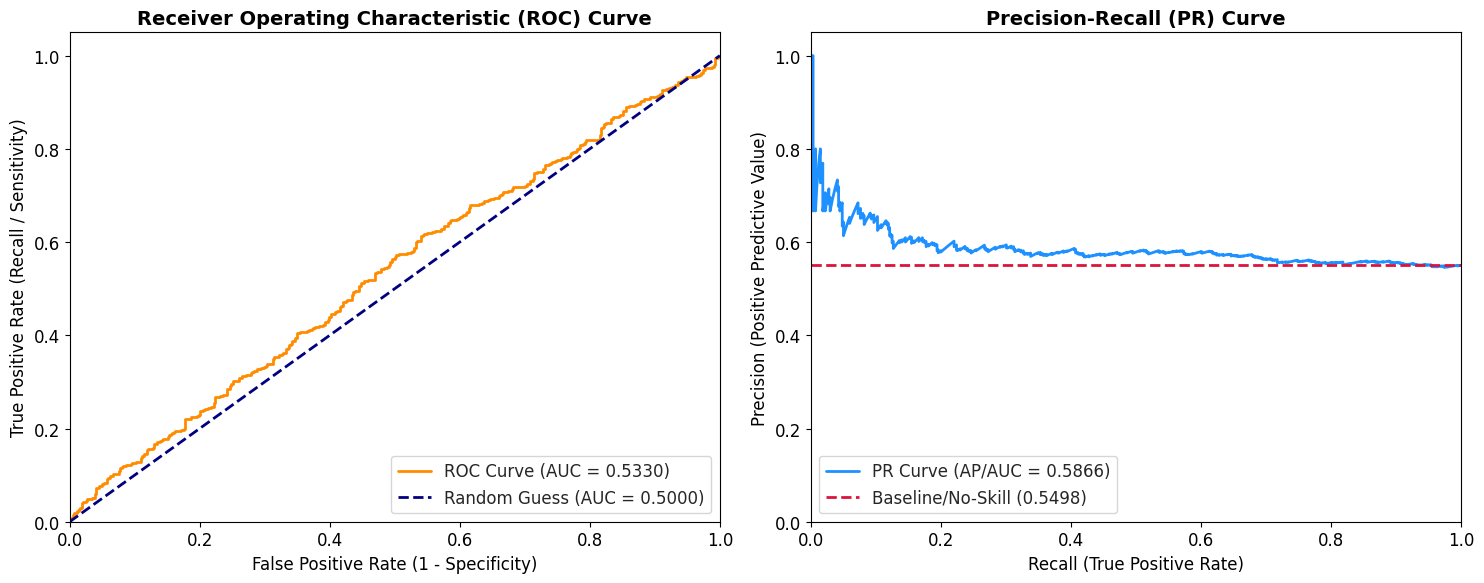

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc, average_precision_score

# 1. Calculate curve coordinates
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc_val = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(y_test, y_probs)
pr_auc_val = average_precision_score(y_test, y_probs) # Robust out-of-the-box calculator

# 2. Set up the plotting canvas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# --- Plot 1: ROC Curve ---
ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc_val:.4f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.5000)')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax1.set_ylabel('True Positive Rate (Recall / Sensitivity)', fontsize=12)
ax1.set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
ax1.legend(loc="lower right", frameon=True)

# --- Plot 2: Precision-Recall Curve ---
# Calculate baseline (no-skill model baseline is the proportion of positive samples)
baseline = sum(y_test) / len(y_test)

ax2.plot(recall, precision, color='dodgerblue', lw=2, label=f'PR Curve (AP/AUC = {pr_auc_val:.4f})')
ax2.axhline(y=baseline, color='crimson', lw=2, linestyle='--', label=f'Baseline/No-Skill ({baseline:.4f})')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall (True Positive Rate)', fontsize=12)
ax2.set_ylabel('Precision (Positive Predictive Value)', fontsize=12)
ax2.set_title('Precision-Recall (PR) Curve', fontsize=14, fontweight='bold')
ax2.legend(loc="lower left", frameon=True)

plt.tight_layout()
plt.show()

### Reading the ROC and PR curves

The orange ROC curve sits almost directly on the diagonal random-guess baseline (AUC 0.5330) —
visual confirmation that the model has very weak overall class-separation ability across the
full range of thresholds, consistent with the near-zero MCC above.

The PR curve is more informative for a trader than the ROC curve here: the red dashed baseline
(0.5498) marks the actual proportion of up-days in the test set — a "no-skill" classifier that
always predicts "Up" would sit on that line. The blue PR curve sits meaningfully above baseline
only in its **low-recall region** (left side of the plot) — exactly where the threshold sweep
above showed Precision climbing above 0.59. That's the operationally useful takeaway: this
model isn't good at classifying *most* days, but its highest-confidence signals (the ones
surviving a strict threshold) are measurably better than a coin flip — useful for a highly
selective, low-frequency strategy, not for trading every signal it produces.


## Summary — Answers to the Five Required Questions

**1. Why can accuracy be misleading here?**
Accuracy (0.5344) is propped up almost entirely by the model's strong bias toward predicting
"Up" (Recall 0.82), while it correctly catches only 81 of 438 actual down-days. It rewards a
model that's directionally biased rather than genuinely predictive — the confusion matrix and
MCC (≈0) tell the real story that accuracy hides.

**2. How much did the CV protocol change the final outcome?**
Substantially, for the tree-based models specifically. Protocol 2 (shuffled K-Fold) inflated
Random Forest's apparent score to 0.5107 — competitive-looking with Logistic Regression — while
its real test score was 0.4502, a **6-point overstatement**. Protocol 3 (nested,
time-respecting CV) never let Random Forest or XGBoost climb above 50%, correctly identifying
both as unreliable from the validation stage itself, before ever touching the test set.

**3. Which cluster showed the largest accuracy drop, and what defines it?**
Cluster 0 — low-volatility (mean 0.0117), narrow-range (mean 205.1) days — which is also 80% of
the entire test set. The model's weakest performance (0.5333 accuracy) is concentrated in the
market's most common, "quiet" behavior, not in rare volatile days.

**4. Is a higher-AUC model necessarily the better trading choice?**
No. AUC (0.5330) summarizes ranking ability averaged across *every* possible threshold,
including many a real strategy would never trade at. MCC (0.0071) and the threshold-specific
F-beta scores tell a more decision-relevant story: at the threshold actually used for trading
(e.g., 0.55–0.60), what matters is Precision and MCC at *that* operating point, not the area
under the full curve.

**5. If only one change were allowed, what should it be, and why?**
**Feature engineering**, not model choice or threshold tuning. Every model here — including the
"winner," Logistic Regression, at only 53.96% test accuracy and MCC ≈ 0 — is barely
distinguishable from chance, and the more complex models (Random Forest, XGBoost) fare *worse*
under honest validation, not better, ruling out "just use a stronger model." The current
features (`RSI`, `MACD`, moving averages, ...) are all lagging derivatives of price itself, and
don't appear to carry meaningful next-day predictive signal on their own. A real jump in
performance would most plausibly need fundamentally different, non-price-derived inputs — order
flow, market sentiment data, or macroeconomic indicators — rather than further tuning of the
existing price-only feature set.
